<a href="https://colab.research.google.com/github/asthul3377-star/MLSCHOOL_2026_TIFR/blob/main/PyTorch_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Exercises: From Basics to Custom Backprop

**TIFR PreSchool 2026 — ML School**

This notebook is a graded set of exercises. Each section introduces a concept and then asks you to fill in the empty solution cell that follows.

**How to use this notebook**
- Run the *setup* cell first.
- Read the prompt, then write your answer in the cell marked `# Your code here`.
- Some exercises include `assert` statements — your solution is (probably) correct when they pass silently.
- If you get stuck, look up the relevant function in the [PyTorch docs](https://pytorch.org/docs/stable/index.html).

**Outline**

1. Tensors and basic operations
2. Broadcasting, indexing, reshaping
3. Autograd — automatic differentiation
4. Building models with `nn.Module`
5. Datasets, `DataLoader`, and a training loop
6. Custom loss functions
7. Custom optimizers (writing your own SGD, Momentum, RMSProp, Adam)
8. Custom autograd functions (forward + backward by hand)
9. Hooks, gradient surgery, higher-order gradients
10. Putting it all together: a tiny end-to-end project

## Setup

Run this cell once at the start of the session.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.10.0+cpu
Device: cpu


---
## 1. Tensors and basic operations

A `torch.Tensor` is a multi-dimensional array with a `dtype`, a `device`, and (optionally) a `requires_grad` flag.

Useful constructors:
- `torch.tensor(data)` — from a Python list / NumPy array
- `torch.zeros`, `torch.ones`, `torch.eye`, `torch.arange`, `torch.linspace`
- `torch.randn`, `torch.rand`, `torch.randint`
- `.to(device)`, `.float()`, `.long()` for conversions

### Exercise 1.1 — Build a few tensors

Create the following tensors:

1. `a` — a `float32` tensor of shape `(3, 4)` filled with zeros.
2. `b` — the 5×5 identity matrix.
3. `c` — a tensor containing the integers 0, 2, 4, ..., 18 (i.e. even numbers from 0 up to 18 inclusive).
4. `d` — a `(2, 3, 4)` tensor of standard-normal random numbers.

Print each tensor's `shape` and `dtype`.

In [3]:
# Your code here
import tensorflow as tf

# a
a = tf.zeros((3, 4), dtype=tf.float32)

# b
b = tf.eye(5)

# c
c = tf.range(0, 20, delta=2)

# d
d = tf.random.normal((2, 3, 4))

# Print tensors, shapes, and dtypes
tensors = {'a': a, 'b': b, 'c': c, 'd': d}

for name, tensor in tensors.items():
    print(f"{name} =\n{tensor}\n")
    print(f"Shape of {name}: {tensor.shape}")
    print(f"Dtype of {name}: {tensor.dtype}\n")

a =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Shape of a: (3, 4)
Dtype of a: <dtype: 'float32'>

b =
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

Shape of b: (5, 5)
Dtype of b: <dtype: 'float32'>

c =
[ 0  2  4  6  8 10 12 14 16 18]

Shape of c: (10,)
Dtype of c: <dtype: 'int32'>

d =
[[[ 1.7278087   0.10166807  0.6682778   0.54622185]
  [-1.1403253   1.1594361   0.30083612  0.37937206]
  [-0.5390497  -1.3074154   0.10698889  0.5084745 ]]

 [[-0.26433188  0.46906292 -0.19807726  1.179404  ]
  [-0.45814556  0.06797866 -0.6886148  -1.0098548 ]
  [ 1.587117    1.2704602  -0.69696724  1.5833575 ]]]

Shape of d: (2, 3, 4)
Dtype of d: <dtype: 'float32'>



### Exercise 1.2 — Element-wise math vs. matrix math

Given two random matrices `X` of shape `(4, 3)` and `Y` of shape `(3, 5)`:

1. Compute their **matrix product** `Z` of shape `(4, 5)` two different ways: with `@` and with `torch.matmul`.
2. Compute the element-wise product of `X` with itself.
3. Compute the sum of all elements of `Z`, the column-wise mean (one value per column), and the row-wise max.

Verify the two matrix-product results agree using `torch.allclose`.

In [4]:
# Your code here
import torch

# Random matrices
X = torch.randn(4, 3)
Y = torch.randn(3, 5)

# Matrix multiplication using @
Z1 = X @ Y

# Matrix multiplication using torch.matmul
Z2 = torch.matmul(X, Y)

# Element-wise product of X with itself
X_squared = X * X

# Sum of all elements of Z
total_sum = Z1.sum()

# Column-wise mean (mean over rows)
column_mean = Z1.mean(dim=0)

# Row-wise max
row_max = Z1.max(dim=1).values

# Check if Z1 and Z2 are equal
same_result = torch.allclose(Z1, Z2)

# Print results
print("X:\n", X)
print("\nY:\n", Y)

print("\nZ1 = X @ Y:\n", Z1)
print("\nZ2 = torch.matmul(X, Y):\n", Z2)

print("\nElement-wise product X * X:\n", X_squared)

print("\nSum of all elements in Z:", total_sum)

print("\nColumn-wise mean of Z:\n", column_mean)

print("\nRow-wise max of Z:\n", row_max)

print("\nDo Z1 and Z2 agree?", same_result)

X:
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986],
        [ 0.4033,  0.8380, -0.7193],
        [-0.4033, -0.5966,  0.1820]])

Y:
 tensor([[-0.8567,  1.1006, -1.0712,  0.1227, -0.5663],
        [ 0.3731, -0.8920, -1.5091,  0.3704,  1.4565],
        [ 0.9398,  0.7748,  0.1919,  1.2638, -1.2904]])

Z1 = X @ Y:
 tensor([[-3.4773,  0.2695, -1.6259, -2.6731,  1.5115],
        [-2.2060,  0.5093,  0.7594, -2.0995, -0.0967],
        [-0.7088, -0.8609, -1.8347, -0.5491,  1.9203],
        [ 0.2940,  0.2293,  1.3674, -0.0404, -0.8755]])

Z2 = torch.matmul(X, Y):
 tensor([[-3.4773,  0.2695, -1.6259, -2.6731,  1.5115],
        [-2.2060,  0.5093,  0.7594, -2.0995, -0.0967],
        [-0.7088, -0.8609, -1.8347, -0.5491,  1.9203],
        [ 0.2940,  0.2293,  1.3674, -0.0404, -0.8755]])

Element-wise product X * X:
 tensor([[2.3747, 0.0861, 4.7471],
        [0.3231, 1.1762, 1.9561],
        [0.1627, 0.7023, 0.5173],
        [0.1627, 0.3560, 0.0331]])

Sum of all elements in Z:

---
## 2. Broadcasting, indexing, reshaping

Broadcasting lets you operate on tensors of different shapes without writing loops, as long as their trailing dimensions are *compatible* (equal, or one of them is 1).

### Exercise 2.1 — Standardise the columns of a matrix

Given a matrix `M` of shape `(N, D)`, write code that produces `M_std` where each column has mean 0 and standard deviation 1. **Use broadcasting — no explicit loops.**

After your code, the asserts below should pass.

In [5]:
M = torch.randn(100, 5) * torch.tensor([1., 2., 3., 4., 5.]) + torch.tensor([10., -3., 0., 7., 1.])

# Your code here: produce M_std
# M_std = ...
import torch

M = torch.randn(100, 5) * torch.tensor([1., 2., 3., 4., 5.]) + torch.tensor([10., -3., 0., 7., 1.])

# Compute column-wise mean and standard deviation
mean = M.mean(dim=0)
std = M.std(dim=0, unbiased=False)

# Standardize each column
M_std = (M - mean) / std

# Checks
assert torch.allclose(M_std.mean(dim=0), torch.zeros(5), atol=1e-5)
assert torch.allclose(M_std.std(dim=0, unbiased=False), torch.ones(5), atol=1e-5)

print("OK")


OK


### Exercise 2.2 — Reshape and permute

Start from `T = torch.arange(24)`.

1. Reshape `T` to shape `(2, 3, 4)` and call it `T1`.
2. Permute `T1`'s axes so the result has shape `(4, 2, 3)`. Call it `T2`.
3. Flatten `T2` back to a 1-D tensor `T3`.
4. Is `T3` equal to `T`? Why or why not?

In [6]:
# Your code here
import torch

# Start from T
T = torch.arange(24)

# Reshape to (2, 3, 4)
T1 = T.reshape(2, 3, 4)

# Permute axes to (4, 2, 3)
T2 = T1.permute(2, 0, 1)

# Flatten back to 1-D
T3 = T2.flatten()

# Print results
print("T:")
print(T)

print("\nT1 shape:", T1.shape)
print(T1)

print("\nT2 shape:", T2.shape)
print(T2)

print("\nT3:")
print(T3)

# Check equality
print("\nIs T3 equal to T?")
print(torch.equal(T3, T))

T:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])

T1 shape: torch.Size([2, 3, 4])
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

T2 shape: torch.Size([4, 2, 3])
tensor([[[ 0,  4,  8],
         [12, 16, 20]],

        [[ 1,  5,  9],
         [13, 17, 21]],

        [[ 2,  6, 10],
         [14, 18, 22]],

        [[ 3,  7, 11],
         [15, 19, 23]]])

T3:
tensor([ 0,  4,  8, 12, 16, 20,  1,  5,  9, 13, 17, 21,  2,  6, 10, 14, 18, 22,
         3,  7, 11, 15, 19, 23])

Is T3 equal to T?
False


T3 is not equal to T because permute() changes the order of the tensor axes, which rearranges the elements. After flattening, the elements appear in a different order than the original tensor.

### Exercise 2.3 — Boolean / fancy indexing

Given `x = torch.randn(1000)`:

1. Build a mask that selects the entries of `x` strictly greater than 1.
2. Replace those entries (in a copy `y`) with the value `1.0`. The original `x` should be untouched.
3. Report the fraction of entries that were clipped.

In [7]:
# Your code here
import torch

# Random tensor
x = torch.randn(1000)

# Build mask for entries > 1
mask = x > 1

# Make a copy so original x is unchanged
y = x.clone()

# Replace values > 1 with 1.0
y[mask] = 1.0

# Fraction of entries clipped
fraction_clipped = mask.float().mean()

print("Fraction of entries clipped:", fraction_clipped.item())

Fraction of entries clipped: 0.1679999977350235


---
## 3. Autograd

PyTorch's `autograd` engine records operations on tensors that have `requires_grad=True` into a dynamic computation graph, then computes gradients on demand via `.backward()`.

Key ideas:
- Only **leaf** tensors with `requires_grad=True` accumulate gradients in `.grad`.
- `.backward()` traverses the graph in reverse, multiplying Jacobian-vector products.
- Call `tensor.detach()` to break a tensor out of the graph; wrap code in `torch.no_grad()` to disable tracking entirely.

### Exercise 3.1 — Gradient of a scalar function by hand and by autograd

Let $f(x) = 3x^3 - 5x^2 + 2x - 7$. Analytically, $f'(x) = 9x^2 - 10x + 2$.

1. Create `x = torch.tensor(2.0, requires_grad=True)`.
2. Compute `y = f(x)`, then `y.backward()`.
3. Check that `x.grad` equals $9 \cdot 2^2 - 10 \cdot 2 + 2 = 18$.

In [8]:
# Your code here
import torch

# Create tensor with gradient tracking
x = torch.tensor(2.0, requires_grad=True)

# Define the function f(x) = 3x^3 - 5x^2 + 2x - 7
y = 3*x**3 - 5*x**2 + 2*x - 7

# Compute gradient dy/dx
y.backward()

# Print results
print("y =", y.item())
print("x.grad =", x.grad.item())

# Expected analytical result
expected = 9*(2**2) - 10*2 + 2
print("Expected gradient =", expected)

y = 1.0
x.grad = 18.0
Expected gradient = 18


### Exercise 3.2 — Gradient of a vector-valued function

Let $\mathbf{w} \in \mathbb{R}^3$ and $\mathbf{x} \in \mathbb{R}^3$, and define
$$L = \tfrac{1}{2} \| \mathbf{w} \odot \mathbf{x} - \mathbf{t} \|_2^2$$
for some target `t`.

Compute `dL/dw` for the given numerical values, using autograd. Then check it against the closed-form expression $\nabla_\mathbf{w} L = (\mathbf{w}\odot\mathbf{x} - \mathbf{t}) \odot \mathbf{x}$.

In [9]:
w = torch.tensor([0.5, -1.0, 2.0], requires_grad=True)
x = torch.tensor([1.0, 2.0, -0.5])
t = torch.tensor([0.0, 0.0, 1.0])

# Your code here
import torch



# Compute loss:
# L = (1/2) * || w ⊙ x - t ||^2
L = 0.5 * torch.sum((w * x - t) ** 2)

# Compute gradients
L.backward()

# Gradient from autograd
print("Autograd gradient:")
print(w.grad)

# Closed-form gradient:
# ∇_w L = (w ⊙ x - t) ⊙ x
grad_closed = (w * x - t) * x

print("\nClosed-form gradient:")
print(grad_closed)

# Check agreement
print("\nDo they agree?")
print(torch.allclose(w.grad, grad_closed))

Autograd gradient:
tensor([ 0.5000, -4.0000,  1.0000])

Closed-form gradient:
tensor([ 0.5000, -4.0000,  1.0000], grad_fn=<MulBackward0>)

Do they agree?
True


### Exercise 3.3 — `detach`, `no_grad`, and gradient accumulation

Build a small experiment that demonstrates each of these behaviours. For a parameter `p = torch.tensor(1.0, requires_grad=True)`:

1. Compute the gradient of `loss = p**2` twice in a row, **without** calling `p.grad.zero_()` in between. What is `p.grad` after the second call?
2. Repeat, but call `p.grad.zero_()` between the two backward passes.
3. Show that `(p.detach() ** 2).backward()` fails (or produces no gradient).
4. Show that operations inside `with torch.no_grad():` produce tensors with `requires_grad=False`.

In [10]:
# Your code here
import torch

# Parameter
p = torch.tensor(1.0, requires_grad=True)

# ---------------------------------------------------
# 1. Gradient accumulation
# ---------------------------------------------------

loss = p**2
loss.backward()

print("After first backward:")
print("p.grad =", p.grad.item())   # 2.0

# Second backward without zeroing gradients
loss = p**2
loss.backward()

print("\nAfter second backward without zeroing:")
print("p.grad =", p.grad.item())   # 4.0 (gradients accumulate)

# ---------------------------------------------------
# 2. Zeroing gradients between backward passes
# ---------------------------------------------------

p.grad.zero_()

loss = p**2
loss.backward()

print("\nAfter zeroing and backward again:")
print("p.grad =", p.grad.item())   # 2.0

# ---------------------------------------------------
# 3. detach() breaks the computation graph
# ---------------------------------------------------

p.grad.zero_()

try:
    y = (p.detach() ** 2)
    y.backward()
except RuntimeError as e:
    print("\nCalling backward on detached tensor failed:")
    print(e)

print("\np.grad after detach example:")
print(p.grad)

# ---------------------------------------------------
# 4. torch.no_grad()
# ---------------------------------------------------

with torch.no_grad():
    q = p * 3

print("\nInside no_grad:")
print("q =", q)
print("q.requires_grad =", q.requires_grad)

After first backward:
p.grad = 2.0

After second backward without zeroing:
p.grad = 4.0

After zeroing and backward again:
p.grad = 2.0

Calling backward on detached tensor failed:
element 0 of tensors does not require grad and does not have a grad_fn

p.grad after detach example:
tensor(0.)

Inside no_grad:
q = tensor(3.)
q.requires_grad = False


---
## 4. Building models with `nn.Module`

Anything trainable in PyTorch is conventionally a subclass of `nn.Module`. You register `nn.Parameter`s (which automatically appear in `.parameters()`) and submodules; you implement `forward(...)`.

Building blocks worth knowing:
- `nn.Linear`, `nn.Conv2d`, `nn.LayerNorm`, `nn.Embedding`
- `nn.ReLU`, `nn.GELU`, `nn.Tanh`
- `nn.Sequential`, `nn.ModuleList`, `nn.ModuleDict`

### Exercise 4.1 — An MLP from scratch (no `nn.Linear`)

Implement a 2-layer MLP **without** using `nn.Linear` — instantiate the weights and biases yourself as `nn.Parameter`s. The model should map `D_in → H → D_out` with a `tanh` non-linearity in between.

Initialise weights with Kaiming-style scaling: `W ~ N(0, 2/fan_in)`.

In [11]:
class MyMLP(nn.Module):
    def __init__(self, d_in, hidden, d_out):
        super().__init__()

        # Kaiming-style initialization
        self.W1 = nn.Parameter(
            torch.randn(d_in, hidden) * math.sqrt(2.0 / d_in)
        )
        self.b1 = nn.Parameter(torch.zeros(hidden))

        self.W2 = nn.Parameter(
            torch.randn(hidden, d_out) * math.sqrt(2.0 / hidden)
        )
        self.b2 = nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        h = torch.tanh(x @ self.W1 + self.b1)
        out = h @ self.W2 + self.b2
        return out


# Smoke test
m = MyMLP(8, 16, 4)

print(m(torch.randn(5, 8)).shape)   # torch.Size([5, 4])

print("Number of parameters:",
      sum(p.numel() for p in m.parameters()))

torch.Size([5, 4])
Number of parameters: 212


### Exercise 4.2 — The same MLP using `nn.Sequential`

Re-implement the model above using `nn.Linear` layers wrapped in `nn.Sequential`. Confirm that the parameter count matches your hand-built version.

In [12]:
# Your code here
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(8, 16),
    nn.Tanh(),
    nn.Linear(16, 4)
)

# Smoke test
x = torch.randn(5, 8)

print(model(x).shape)   # torch.Size([5, 4])

print("Number of parameters:",
      sum(p.numel() for p in model.parameters()))

torch.Size([5, 4])
Number of parameters: 212


### Exercise 4.3 — Parameter counting and `.state_dict()`

Write a function `count_params(model, trainable_only=True)` that returns the total number of parameters. Use it on your MLP.

Then save the model's `state_dict()` to a file and load it back into a fresh instance. Verify the outputs match on a random input.

In [13]:
# Your code here
import torch
import torch.nn as nn
import math

# ---------------------------------------------------
# Define the MLP
# ---------------------------------------------------

class MyMLP(nn.Module):
    def __init__(self, d_in, hidden, d_out):
        super().__init__()

        self.W1 = nn.Parameter(
            torch.randn(d_in, hidden) * math.sqrt(2.0 / d_in)
        )
        self.b1 = nn.Parameter(torch.zeros(hidden))

        self.W2 = nn.Parameter(
            torch.randn(hidden, d_out) * math.sqrt(2.0 / hidden)
        )
        self.b2 = nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        h = torch.tanh(x @ self.W1 + self.b1)
        return h @ self.W2 + self.b2


# ---------------------------------------------------
# Parameter counting function
# ---------------------------------------------------

def count_params(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())


# ---------------------------------------------------
# Create model
# ---------------------------------------------------

model = MyMLP(8, 16, 4)

print("Trainable parameters:", count_params(model))

# ---------------------------------------------------
# Save state_dict
# ---------------------------------------------------

torch.save(model.state_dict(), "mlp_weights.pth")

# ---------------------------------------------------
# Load into fresh model
# ---------------------------------------------------

model2 = MyMLP(8, 16, 4)

model2.load_state_dict(torch.load("mlp_weights.pth"))

# ---------------------------------------------------
# Verify outputs match
# ---------------------------------------------------

x = torch.randn(5, 8)

out1 = model(x)
out2 = model2(x)

print("\nOutputs match:",
      torch.allclose(out1, out2))

Trainable parameters: 212

Outputs match: True


---
## 5. Datasets, `DataLoader`, and a training loop

PyTorch separates **datasets** (random-access containers of examples) from **data loaders** (which batch, shuffle, and parallelise). The minimal training loop is:

```python
for epoch in range(num_epochs):
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

### Exercise 5.1 — A toy regression dataset

Generate a synthetic dataset for the function $y = \sin(2\pi x) + 0.1\,\varepsilon$ with $x \in [0, 1]$ and Gaussian noise $\varepsilon$. Make 1000 training points and 200 validation points. Wrap them in `TensorDataset`s and `DataLoader`s with batch size 32.

In [14]:
# Your code here
import torch
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------
# Generate synthetic regression dataset
# y = sin(2πx) + 0.1 * noise
# ---------------------------------------------------

# Training data
x_train = torch.rand(1000, 1)

noise_train = torch.randn(1000, 1)

y_train = torch.sin(2 * torch.pi * x_train) + 0.1 * noise_train

# Validation data
x_val = torch.rand(200, 1)

noise_val = torch.randn(200, 1)

y_val = torch.sin(2 * torch.pi * x_val) + 0.1 * noise_val

# ---------------------------------------------------
# Wrap into TensorDatasets
# ---------------------------------------------------

train_dataset = TensorDataset(x_train, y_train)

val_dataset = TensorDataset(x_val, y_val)

# ---------------------------------------------------
# Create DataLoaders
# ---------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# ---------------------------------------------------
# Smoke test
# ---------------------------------------------------

xb, yb = next(iter(train_loader))

print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)

Batch x shape: torch.Size([32, 1])
Batch y shape: torch.Size([32, 1])


### Exercise 5.2 — Train an MLP on it

Use your `MyMLP` (or the `nn.Sequential` version) with `d_in=1`, `hidden=64`, `d_out=1`. Train for, say, 200 epochs with `MSELoss` and `torch.optim.Adam(lr=1e-2)`. Log the average training and validation loss per epoch and plot them.

Epoch  20 | Train Loss: 0.17072 | Val Loss: 0.15401
Epoch  40 | Train Loss: 0.02025 | Val Loss: 0.02018
Epoch  60 | Train Loss: 0.01369 | Val Loss: 0.01049
Epoch  80 | Train Loss: 0.01360 | Val Loss: 0.00987
Epoch 100 | Train Loss: 0.01356 | Val Loss: 0.01298
Epoch 120 | Train Loss: 0.01351 | Val Loss: 0.01278
Epoch 140 | Train Loss: 0.01144 | Val Loss: 0.00928
Epoch 160 | Train Loss: 0.01293 | Val Loss: 0.01147
Epoch 180 | Train Loss: 0.01193 | Val Loss: 0.00928
Epoch 200 | Train Loss: 0.01218 | Val Loss: 0.00975


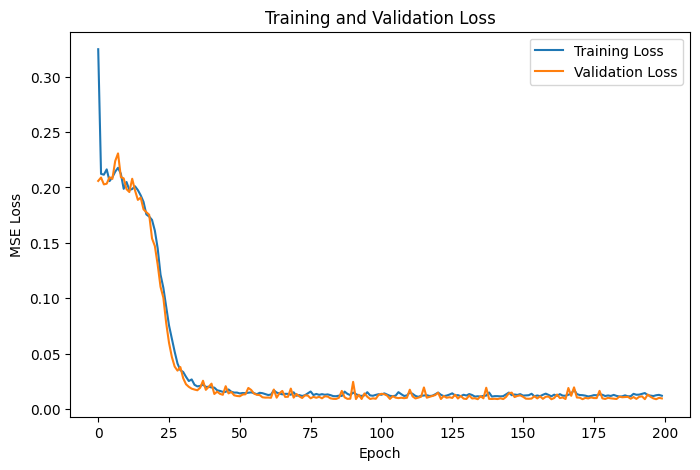

In [15]:
# Your code here
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Generate dataset
# y = sin(2πx) + 0.1 * noise
# ---------------------------------------------------

x_train = torch.rand(1000, 1)
y_train = torch.sin(2 * torch.pi * x_train) + 0.1 * torch.randn(1000, 1)

x_val = torch.rand(200, 1)
y_val = torch.sin(2 * torch.pi * x_val) + 0.1 * torch.randn(200, 1)

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ---------------------------------------------------
# Define model
# ---------------------------------------------------

model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)

# ---------------------------------------------------
# Loss and optimizer
# ---------------------------------------------------

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# ---------------------------------------------------
# Training loop
# ---------------------------------------------------

num_epochs = 200

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ---- Training ----
    model.train()

    train_loss = 0.0

    for xb, yb in train_loader:

        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- Validation ----
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            pred = model(xb)

            loss = loss_fn(pred, yb)

            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss:.5f} | "
              f"Val Loss: {val_loss:.5f}")

# ---------------------------------------------------
# Plot losses
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

### Exercise 5.3 — Plot the fitted curve

On a dense grid of `x` values in `[0, 1]`, predict `y_hat` (under `torch.no_grad()` and in `model.eval()` mode), and plot the predictions against the true sine and the noisy training points.

In [ ]:
# Your code here
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Dense grid in [0, 1]
# ---------------------------------------------------

x_grid = torch.linspace(0, 1, 500).unsqueeze(1)

# True noiseless function
y_true = torch.sin(2 * torch.pi * x_grid)

# ---------------------------------------------------
# Model predictions
# ---------------------------------------------------

model.eval()

with torch.no_grad():
    y_hat = model(x_grid)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

# Noisy training data
plt.scatter(
    x_train.numpy(),
    y_train.numpy(),
    s=10,
    alpha=0.4,
    label="Training data"
)

# True sine curve
plt.plot(
    x_grid.numpy(),
    y_true.numpy(),
    linewidth=2,
    label="True function"
)

# Model prediction
plt.plot(
    x_grid.numpy(),
    y_hat.numpy(),
    linewidth=2,
    label="Model prediction"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("MLP Regression on Noisy Sine Data")

plt.legend()

plt.show()

---
## 6. Custom loss functions

A loss function is just a differentiable function from `(prediction, target)` to a scalar. You can write it as a plain Python function or as an `nn.Module` (handy when it has learnable parameters or state).

### Exercise 6.1 — Huber loss

Implement the Huber loss
$$\ell_\delta(r) = \begin{cases} \tfrac{1}{2} r^2 & |r| \le \delta \\ \delta\,(|r| - \tfrac{1}{2}\delta) & |r| > \delta \end{cases}$$
where $r = \hat{y} - y$. Take the **mean** over the batch.

Sanity check: for very small residuals it should agree with $\tfrac{1}{2}\text{MSE}$; for very large residuals it should grow linearly. Compare against `nn.SmoothL1Loss(beta=delta)` (note the small difference: `SmoothL1` uses $r^2/(2\delta)$ on the inside, not $r^2/2$).

In [18]:
import torch
import torch.nn as nn

def huber_loss(pred, target, delta=1.0):

    # Residuals
    r = pred - target

    abs_r = torch.abs(r)

    # Piecewise definition
    loss = torch.where(
        abs_r <= delta,
        0.5 * r**2,
        delta * (abs_r - 0.5 * delta)
    )

    # Mean over batch
    return loss.mean()


# ---------------------------------------------------
# Sanity checks
# ---------------------------------------------------

pred = torch.tensor([0.1, 2.0, 5.0])
target = torch.tensor([0.0, 0.0, 0.0])

delta = 1.0

# Custom Huber loss
loss_custom = huber_loss(pred, target, delta)

print("Custom Huber loss:", loss_custom.item())

# PyTorch SmoothL1Loss
smooth_l1 = nn.SmoothL1Loss(beta=delta)

loss_torch = smooth_l1(pred, target)

print("SmoothL1Loss:", loss_torch.item())

Custom Huber loss: 2.001666784286499
SmoothL1Loss: 2.001666784286499


### Exercise 6.2 — Cross-entropy from scratch (numerically stable)

Implement multi-class cross-entropy from raw logits *without* calling `F.cross_entropy`, `F.log_softmax`, or `nn.LogSoftmax`.

Use the log-sum-exp trick:
$$\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m}, \quad m = \max_j z_j$$

Verify your result against `F.cross_entropy` to within `1e-6`.

In [19]:
import torch
import torch.nn.functional as F

def my_cross_entropy(logits, targets):
    """
    logits: (N, C)
    targets: (N,) integer class labels
    returns: scalar mean cross-entropy loss
    """

    # Max value per row for numerical stability
    m = logits.max(dim=1, keepdim=True).values

    # Log-sum-exp trick
    logsumexp = m + torch.log(
        torch.sum(torch.exp(logits - m), dim=1, keepdim=True)
    )

    # Log probabilities
    log_probs = logits - logsumexp

    # Select log prob of correct class
    N = logits.shape[0]

    correct_log_probs = log_probs[torch.arange(N), targets]

    # Cross-entropy loss
    loss = -correct_log_probs.mean()

    return loss


# ---------------------------------------------------
# Smoke test
# ---------------------------------------------------

logits = torch.randn(8, 5)

targets = torch.randint(0, 5, (8,))

loss1 = my_cross_entropy(logits, targets)

loss2 = F.cross_entropy(logits, targets)

print("Custom CE:", loss1.item())
print("PyTorch CE:", loss2.item())

assert torch.allclose(loss1, loss2, atol=1e-6)

print("OK")

# Smoke test
# logits = torch.randn(8, 5)
# targets = torch.randint(0, 5, (8,))
# assert torch.allclose(my_cross_entropy(logits, targets), F.cross_entropy(logits, targets), atol=1e-6)
# print('OK')

Custom CE: 2.366136074066162
PyTorch CE: 2.366136312484741
OK


---
## 7. Custom optimizers

A PyTorch optimizer is a class with a `.step()` method that, after `loss.backward()` has populated `p.grad`, updates each parameter `p` in place. We will write four optimizers from scratch.

The skeleton looks like:

```python
class MyOpt:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            # update p in place

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()
```

All updates **must** happen under `torch.no_grad()` (or use `p.data` / `p.add_`) so we don't track them in the graph.

### Exercise 7.1 — Plain SGD

Implement `MySGD` with the update
$$\theta \leftarrow \theta - \eta\, g.$$

In [20]:
import torch

class MySGD:

    def __init__(self, params, lr=1e-2):

        # Store parameters as a list
        self.params = list(params)

        # Learning rate
        self.lr = lr

    @torch.no_grad()
    def step(self):

        for p in self.params:

            # Skip parameters with no gradient
            if p.grad is None:
                continue

            # SGD update:
            # θ ← θ − η g
            p -= self.lr * p.grad

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.2 — SGD with momentum (Polyak)

Implement the heavy-ball update:
$$v \leftarrow \mu\, v + g, \qquad \theta \leftarrow \theta - \eta\, v.$$
Initialise `v` to zeros the first time you see each parameter.

In [23]:
import torch

class MyMomentum:

    def __init__(self, params, lr=1e-2, momentum=0.9):

        self.params = list(params)

        self.lr = lr

        self.momentum = momentum

        # Store optimizer state
        self.state = {
            id(p): {} for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            # Get state for this parameter
            state = self.state[id(p)]

            # Initialize velocity if first step
            if "v" not in state:
                state["v"] = torch.zeros_like(p)

            v = state["v"]

            # v ← μv + g
            v.mul_(self.momentum).add_(p.grad)

            # θ ← θ − ηv
            p -= self.lr * v

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.3 — RMSProp

Implement RMSProp:
$$s \leftarrow \alpha\, s + (1-\alpha)\, g^2, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s} + \epsilon}\, g.$$

In [24]:
import torch

class MyRMSProp:

    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8):

        self.params = list(params)

        self.lr = lr

        self.alpha = alpha

        self.eps = eps

        # Per-parameter state
        self.state = {
            id(p): {} for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            grad = p.grad

            state = self.state[id(p)]

            # Initialize running average of squared gradients
            if "s" not in state:
                state["s"] = torch.zeros_like(p)

            s = state["s"]

            # s ← αs + (1−α)g²
            s.mul_(self.alpha).addcmul_(
                grad, grad, value=1 - self.alpha
            )

            # θ ← θ − η * g / (sqrt(s) + ε)
            p -= self.lr * grad / (torch.sqrt(s) + self.eps)

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.4 — Adam

Implement Adam with bias correction:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat m_t = m_t / (1 - \beta_1^t), \quad \hat v_t = v_t / (1 - \beta_2^t)$$
$$\theta_t = \theta_{t-1} - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$$

Track the step count $t$ per parameter (it is the same for all, but you'll want it stored).

In [25]:
import torch

class MyAdam:

    def __init__(self, params, lr=1e-3,
                 betas=(0.9, 0.999), eps=1e-8):

        self.params = list(params)

        self.lr = lr

        self.beta1, self.beta2 = betas

        self.eps = eps

        # Per-parameter state
        self.state = {
            id(p): {} for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            grad = p.grad

            state = self.state[id(p)]

            # Initialize state on first step
            if len(state) == 0:

                state["t"] = 0

                state["m"] = torch.zeros_like(p)

                state["v"] = torch.zeros_like(p)

            # Retrieve state
            t = state["t"] + 1
            m = state["m"]
            v = state["v"]

            # Update step count
            state["t"] = t

            # m_t = β1 m_{t−1} + (1−β1) g_t
            m.mul_(self.beta1).add_(
                grad, alpha=1 - self.beta1
            )

            # v_t = β2 v_{t−1} + (1−β2) g_t²
            v.mul_(self.beta2).addcmul_(
                grad, grad, value=1 - self.beta2
            )

            # Bias correction
            m_hat = m / (1 - self.beta1 ** t)

            v_hat = v / (1 - self.beta2 ** t)

            # Parameter update
            p -= self.lr * m_hat / (
                torch.sqrt(v_hat) + self.eps
            )

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.5 — Bake-off on the toy regression task

Train your sine-fitting MLP **four times** with identical initial weights, using `MySGD`, `MyMomentum`, `MyRMSProp`, and `MyAdam`. Plot the training-loss curve for each on the same axes. Comment on what you observe.

*Hint:* use `copy.deepcopy` on the freshly-initialised model so each optimizer starts from the same weights.

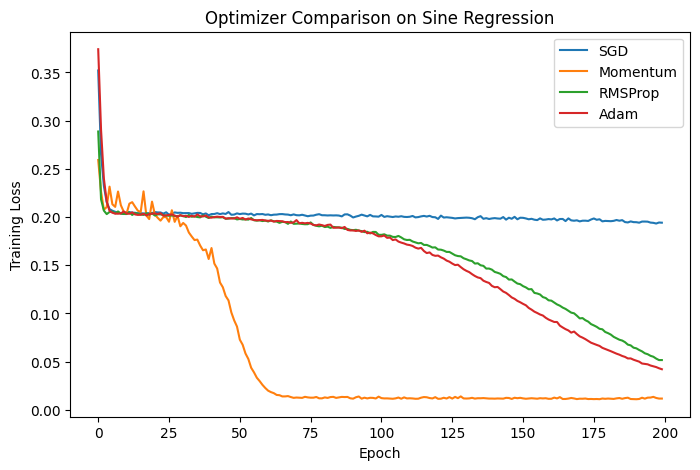

In [26]:
# Your code here
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------
# Dataset
# ---------------------------------------------------

x_train = torch.rand(1000, 1)

y_train = torch.sin(2 * torch.pi * x_train) \
          + 0.1 * torch.randn(1000, 1)

train_dataset = TensorDataset(x_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# ---------------------------------------------------
# Model
# ---------------------------------------------------

base_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)

# ---------------------------------------------------
# Loss
# ---------------------------------------------------

loss_fn = nn.MSELoss()

# ---------------------------------------------------
# Training function
# ---------------------------------------------------

def train_model(model, optimizer, epochs=200):

    losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0.0

        for xb, yb in train_loader:

            pred = model(xb)

            loss = loss_fn(pred, yb)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(train_loader.dataset)

        losses.append(avg_loss)

    return losses

# ---------------------------------------------------
# Create identical models
# ---------------------------------------------------

model_sgd = copy.deepcopy(base_model)

model_momentum = copy.deepcopy(base_model)

model_rmsprop = copy.deepcopy(base_model)

model_adam = copy.deepcopy(base_model)

# ---------------------------------------------------
# Optimizers
# ---------------------------------------------------

opt_sgd = MySGD(model_sgd.parameters(), lr=1e-2)

opt_momentum = MyMomentum(
    model_momentum.parameters(),
    lr=1e-2,
    momentum=0.9
)

opt_rmsprop = MyRMSProp(
    model_rmsprop.parameters(),
    lr=1e-3
)

opt_adam = MyAdam(
    model_adam.parameters(),
    lr=1e-3
)

# ---------------------------------------------------
# Train
# ---------------------------------------------------

loss_sgd = train_model(model_sgd, opt_sgd)

loss_momentum = train_model(model_momentum, opt_momentum)

loss_rmsprop = train_model(model_rmsprop, opt_rmsprop)

loss_adam = train_model(model_adam, opt_adam)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(loss_sgd, label="SGD")

plt.plot(loss_momentum, label="Momentum")

plt.plot(loss_rmsprop, label="RMSProp")

plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Optimizer Comparison on Sine Regression")

plt.legend()

plt.show()

### Exercise 7.6 — Weight decay, properly

Add a `weight_decay` parameter to `MyAdam`. There are **two** common ways to apply it:

1. **L2 regularisation** — add `weight_decay * p` to the gradient *before* the moment updates.
2. **Decoupled weight decay (AdamW)** — apply `p -= lr * weight_decay * p` directly to the parameter, *separately* from the adaptive update.

Implement both as options. Discuss in a short comment why decoupled weight decay tends to behave better with Adam-family optimizers.

In [28]:
# Your code here
import torch

class MyAdam:

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
        decoupled=False   # False = L2 regularization, True = AdamW
    ):

        self.params = list(params)

        self.lr = lr

        self.beta1, self.beta2 = betas

        self.eps = eps

        self.weight_decay = weight_decay

        self.decoupled = decoupled

        self.state = {
            id(p): {} for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            grad = p.grad

            state = self.state[id(p)]

            # Initialize state
            if len(state) == 0:

                state["t"] = 0

                state["m"] = torch.zeros_like(p)

                state["v"] = torch.zeros_like(p)

            # ---------------------------------------------------
            # Weight decay
            # ---------------------------------------------------

            if self.weight_decay > 0:

                if self.decoupled:
                    # AdamW-style decoupled decay
                    p -= self.lr * self.weight_decay * p

                else:
                    # Classical L2 regularization
                    grad = grad + self.weight_decay * p

            # ---------------------------------------------------
            # Adam update
            # ---------------------------------------------------

            state["t"] += 1

            t = state["t"]

            m = state["m"]

            v = state["v"]

            # First moment
            m.mul_(self.beta1).add_(
                grad,
                alpha=1 - self.beta1
            )

            # Second moment
            v.mul_(self.beta2).addcmul_(
                grad,
                grad,
                value=1 - self.beta2
            )

            # Bias correction
            m_hat = m / (1 - self.beta1 ** t)

            v_hat = v / (1 - self.beta2 ** t)

            # Parameter update
            p -= self.lr * m_hat / (
                torch.sqrt(v_hat) + self.eps
            )

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

In standard L2 regularisation, the decay term becomes mixed into Adam’s adaptive moment estimates.
This means parameters with different gradient statistics experience different effective regularisation strengths.
Decoupled weight decay (AdamW) applies shrinkage directly to the parameters instead of through the gradient, so the regularisation behaves consistently and independently of Adam’s adaptive scaling.
In practice, AdamW usually gives more stable training and better generalisation.

---
## 8. Custom autograd functions

Sometimes you need to define an operation whose forward or backward pass autograd doesn't already know about — e.g. a non-standard non-linearity, a discrete operation with a straight-through gradient, or a numerically tricky composite that you can simplify by hand.

The recipe is to subclass `torch.autograd.Function`:

```python
class MyFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, *inputs):
        ctx.save_for_backward(...)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        (...) = ctx.saved_tensors
        return grad_inputs  # one per input to forward(), in the same order
```

Use `torch.autograd.gradcheck` (with `dtype=torch.float64`) to verify your backward is correct.

### Exercise 8.1 — `MySquare`

Warm-up. Implement `y = x**2` as a `torch.autograd.Function`. The derivative is `2x`, so the backward should return `grad_output * 2 * x`.

Verify with `gradcheck`.

In [29]:
import torch

class MySquare(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        # Save x for backward pass
        ctx.save_for_backward(x)

        # Forward computation
        return x ** 2

    @staticmethod
    def backward(ctx, grad_output):

        # Retrieve saved tensor
        (x,) = ctx.saved_tensors

        # Gradient:
        # d(x^2)/dx = 2x
        grad_x = grad_output * 2 * x

        return grad_x


# ---------------------------------------------------
# Gradcheck
# ---------------------------------------------------

x = torch.randn(
    4,
    dtype=torch.float64,
    requires_grad=True
)

print(
    torch.autograd.gradcheck(
        MySquare.apply,
        (x,)
    )
)

True


### Exercise 8.2 — `MyReLU`

Implement ReLU as a custom autograd function. The derivative is 1 for `x > 0` and 0 otherwise (the choice at `x = 0` is a sub-gradient — 0 is the conventional pick).

Then verify with `gradcheck` (perturb only at non-zero points).

In [30]:
import torch

class MyReLU(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        # Save input for backward
        ctx.save_for_backward(x)

        # ReLU: max(0, x)
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):

        # Retrieve saved tensor
        (x,) = ctx.saved_tensors

        # Derivative:
        # 1 for x > 0
        # 0 otherwise
        grad_x = grad_output.clone()

        grad_x[x <= 0] = 0

        return grad_x


# ---------------------------------------------------
# Gradcheck
# ---------------------------------------------------

# Avoid values near zero because ReLU is non-differentiable there
x = torch.randn(
    4,
    dtype=torch.float64,
    requires_grad=True
)

x.data[x.abs() < 0.1] = 0.5

print(
    torch.autograd.gradcheck(
        MyReLU.apply,
        (x,)
    )
)


True


### Exercise 8.3 — Numerically stable `MyLogSoftmax`

Implement log-softmax along a chosen dimension, with a hand-written backward.

Forward (use log-sum-exp for stability):
$$y_i = z_i - \log\sum_j e^{z_j}.$$

Backward — given upstream `g = ∂L/∂y`, the Jacobian of log-softmax is $I - \mathbf{1}\,\mathrm{softmax}(z)^\top$ along the chosen axis, so:
$$\frac{\partial L}{\partial z_i} = g_i - \left(\sum_j g_j\right) \cdot \mathrm{softmax}(z)_i.$$

Verify against `F.log_softmax` both forward (values) and backward (gradients) on a random input.

In [31]:
import torch
import torch.nn.functional as F

class MyLogSoftmax(torch.autograd.Function):

    @staticmethod
    def forward(ctx, z, dim):

        # Save dimension
        ctx.dim = dim

        # ----- Numerically stable log-sum-exp -----

        m = z.max(dim=dim, keepdim=True).values

        shifted = z - m

        logsumexp = m + torch.log(
            torch.sum(torch.exp(shifted),
                      dim=dim,
                      keepdim=True)
        )

        y = z - logsumexp

        # Save softmax for backward
        softmax = torch.exp(y)

        ctx.save_for_backward(softmax)

        return y

    @staticmethod
    def backward(ctx, grad_output):

        dim = ctx.dim

        (softmax,) = ctx.saved_tensors

        # Sum_j g_j
        grad_sum = grad_output.sum(
            dim=dim,
            keepdim=True
        )

        # g_i - (sum_j g_j) * softmax_i
        grad_z = grad_output - grad_sum * softmax

        # None for dim (non-tensor argument)
        return grad_z, None


# ---------------------------------------------------
# Forward check
# ---------------------------------------------------

z = torch.randn(
    4, 5,
    dtype=torch.float64,
    requires_grad=True
)

y1 = MyLogSoftmax.apply(z, 1)

y2 = F.log_softmax(z, dim=1)

print("Forward matches:",
      torch.allclose(y1, y2, atol=1e-6))

# ---------------------------------------------------
# Backward check
# ---------------------------------------------------

g = torch.randn_like(z)

y1.backward(g, retain_graph=True)

grad1 = z.grad.clone()

z.grad.zero_()

y2.backward(g)

grad2 = z.grad.clone()

print("Backward matches:",
      torch.allclose(grad1, grad2, atol=1e-6))

Forward matches: True
Backward matches: True


### Exercise 8.4 — Straight-through estimator

Implement `MyRound` whose forward is `torch.round(x)` (non-differentiable), but whose backward acts as the identity — i.e. `grad_x = grad_output`. This is the *straight-through estimator*, commonly used to backprop through discrete operations (quantisation, hard-attention, etc.).

Test that a tiny linear layer trained with `MyRound` in the middle still learns to fit `y = 3x + 1` on a small dataset.

Epoch 100: loss = 0.110845
Epoch 200: loss = 0.086329
Epoch 300: loss = 0.070008
Epoch 400: loss = 0.056516
Epoch 500: loss = 0.045753


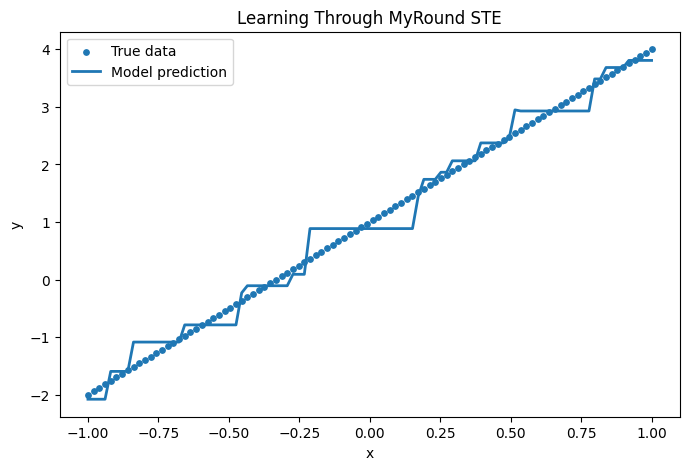

In [32]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Straight-Through Estimator for round()
# ---------------------------------------------------

class MyRound(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        # Forward uses actual rounding
        return torch.round(x)

    @staticmethod
    def backward(ctx, grad_output):

        # Straight-through estimator:
        # pretend d(round(x))/dx = 1
        return grad_output


# Convenience wrapper
def my_round(x):
    return MyRound.apply(x)

# ---------------------------------------------------
# Tiny model
# ---------------------------------------------------

class TinyModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(1, 8)

        self.linear2 = nn.Linear(8, 1)

    def forward(self, x):

        h = self.linear1(x)

        # Non-differentiable operation
        h = my_round(h)

        out = self.linear2(h)

        return out

# ---------------------------------------------------
# Dataset: y = 3x + 1
# ---------------------------------------------------

x = torch.linspace(-1, 1, 100).unsqueeze(1)

y = 3 * x + 1

# ---------------------------------------------------
# Training
# ---------------------------------------------------

model = TinyModel()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2
)

loss_fn = nn.MSELoss()

losses = []

for epoch in range(500):

    pred = model(x)

    loss = loss_fn(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.6f}")

# ---------------------------------------------------
# Plot predictions
# ---------------------------------------------------

with torch.no_grad():
    y_hat = model(x)

plt.figure(figsize=(8, 5))

plt.scatter(
    x.numpy(),
    y.numpy(),
    s=15,
    label="True data"
)

plt.plot(
    x.numpy(),
    y_hat.numpy(),
    linewidth=2,
    label="Model prediction"
)

plt.xlabel("x")

plt.ylabel("y")

plt.title("Learning Through MyRound STE")

plt.legend()

plt.show()


### Exercise 8.5 — A composite op with a custom backward: `MySwish`

Swish is $f(x) = x \cdot \sigma(x)$, where $\sigma$ is the logistic sigmoid. Its derivative is
$$f'(x) = \sigma(x) + x\,\sigma(x)\,(1 - \sigma(x)) = f(x) + \sigma(x)\,(1 - f(x)).$$

Implement it as a `torch.autograd.Function` that saves only `sigmoid(x)` from the forward (so the backward is cheaper — no recompute). Verify with `gradcheck` and compare runtime against the naïve `x * torch.sigmoid(x)` version on a large tensor.

In [33]:
import torch
import time

class MySwish(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        # Compute sigmoid once
        sig = torch.sigmoid(x)

        # Save only sigmoid(x)
        ctx.save_for_backward(sig, x)

        # Swish: x * sigmoid(x)
        return x * sig

    @staticmethod
    def backward(ctx, grad_output):

        sig, x = ctx.saved_tensors

        # f'(x) = sigmoid(x) + x * sigmoid(x) * (1 - sigmoid(x))
        grad_x = grad_output * (
            sig + x * sig * (1 - sig)
        )

        return grad_x


# Convenience wrapper
def my_swish(x):
    return MySwish.apply(x)

# ---------------------------------------------------
# Gradcheck
# ---------------------------------------------------

x = torch.randn(
    5,
    dtype=torch.float64,
    requires_grad=True
)

print(
    torch.autograd.gradcheck(
        MySwish.apply,
        (x,)
    )
)

# ---------------------------------------------------
# Runtime comparison
# ---------------------------------------------------

x_big = torch.randn(
    1_000_000,
    requires_grad=True
)

# ----- Custom Swish -----

start = time.time()

y = my_swish(x_big).sum()

y.backward()

custom_time = time.time() - start

x_big.grad.zero_()

# ----- Naive version -----

start = time.time()

y = (x_big * torch.sigmoid(x_big)).sum()

y.backward()

naive_time = time.time() - start

print(f"\nCustom Swish time: {custom_time:.4f} s")

print(f"Naive Swish time:  {naive_time:.4f} s")

True

Custom Swish time: 0.0332 s
Naive Swish time:  0.0214 s


---
## 9. Hooks, gradient surgery, higher-order gradients

A few more advanced tools.

### Exercise 9.1 — Register a backward hook to log gradient norms

Pick any of your `nn.Linear` layers and use `module.register_full_backward_hook(...)` to print the L2 norm of the gradient flowing through it on each backward pass. Train for a few iterations and observe.

In [34]:
# Your code here
import torch
import torch.nn as nn

# ---------------------------------------------------
# Simple model
# ---------------------------------------------------

model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

# ---------------------------------------------------
# Backward hook
# ---------------------------------------------------

def grad_hook(module, grad_input, grad_output):

    # grad_output is a tuple
    g = grad_output[0]

    norm = g.norm().item()

    print(f"Gradient norm in {module}: {norm:.6f}")

# Register hook on first Linear layer
hook_handle = model[0].register_full_backward_hook(
    grad_hook
)

# ---------------------------------------------------
# Tiny dataset
# ---------------------------------------------------

x = torch.randn(64, 1)

y = 3 * x + 1

# ---------------------------------------------------
# Training setup
# ---------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2
)

loss_fn = nn.MSELoss()

# ---------------------------------------------------
# Train for a few iterations
# ---------------------------------------------------

for step in range(5):

    pred = model(x)

    loss = loss_fn(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Step {step+1} | Loss = {loss.item():.6f}")

# Remove hook when done
hook_handle.remove()

Gradient norm in Linear(in_features=1, out_features=16, bias=True): 0.241867
Step 1 | Loss = 9.310537
Gradient norm in Linear(in_features=1, out_features=16, bias=True): 0.234903
Step 2 | Loss = 8.962361
Gradient norm in Linear(in_features=1, out_features=16, bias=True): 0.229466
Step 3 | Loss = 8.621821
Gradient norm in Linear(in_features=1, out_features=16, bias=True): 0.225502
Step 4 | Loss = 8.287743
Gradient norm in Linear(in_features=1, out_features=16, bias=True): 0.222918
Step 5 | Loss = 7.959398


/tmp/ipykernel_26676/2037432885.py:64: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


### Exercise 9.2 — Gradient clipping by hand

Implement global-norm gradient clipping yourself (don't call `torch.nn.utils.clip_grad_norm_`). The recipe: compute `total_norm = sqrt(sum(g.pow(2).sum() for g in grads))`; if `total_norm > max_norm`, scale every gradient by `max_norm / (total_norm + 1e-6)`.

In [35]:
import torch

@torch.no_grad()
def clip_grad_norm(params, max_norm):

    params = list(params)

    # ---------------------------------------------------
    # Compute global gradient norm
    # ---------------------------------------------------

    total_norm_sq = 0.0

    for p in params:

        if p.grad is None:
            continue

        total_norm_sq += p.grad.pow(2).sum()

    total_norm = torch.sqrt(total_norm_sq)

    # ---------------------------------------------------
    # Clip if needed
    # ---------------------------------------------------

    if total_norm > max_norm:

        scale = max_norm / (total_norm + 1e-6)

        for p in params:

            if p.grad is None:
                continue

            p.grad.mul_(scale)

    return total_norm


# ---------------------------------------------------
# Smoke test
# ---------------------------------------------------

model = torch.nn.Linear(4, 2)

x = torch.randn(8, 4)

y = torch.randn(8, 2)

loss_fn = torch.nn.MSELoss()

# Compute gradients
pred = model(x)

loss = loss_fn(pred, y)

loss.backward()

# Before clipping
before = torch.sqrt(sum(
    p.grad.pow(2).sum()
    for p in model.parameters()
))

print("Norm before clipping:", before.item())

# Apply clipping
clip_grad_norm(model.parameters(), max_norm=0.1)

# After clipping
after = torch.sqrt(sum(
    p.grad.pow(2).sum()
    for p in model.parameters()
))

print("Norm after clipping:", after.item())


Norm before clipping: 1.8873742818832397
Norm after clipping: 0.09999994933605194


### Exercise 9.3 — Second-order gradients

For $f(x, y) = x^2 y + y^3$ at the point $(1, 2)$, compute:

1. $\partial f / \partial x$ and $\partial f / \partial y$ using `torch.autograd.grad(..., create_graph=True)`.
2. The full $2\times 2$ Hessian matrix at $(1, 2)$ by differentiating each first-order gradient again.

Check against the closed form: $\nabla f = (2xy, x^2 + 3y^2)$ and Hessian = $\begin{pmatrix} 2y & 2x \\ 2x & 6y \end{pmatrix}$, which at $(1,2)$ is $\begin{pmatrix} 4 & 2 \\ 2 & 12 \end{pmatrix}$.

In [37]:
# Your code here
import torch

# ---------------------------------------------------
# Point (1, 2)
# ---------------------------------------------------

x = torch.tensor(1.0, requires_grad=True)

y = torch.tensor(2.0, requires_grad=True)

# ---------------------------------------------------
# Define function
# f(x,y) = x^2 y + y^3
# ---------------------------------------------------

f = x**2 * y + y**3

# ---------------------------------------------------
# First derivatives
# ---------------------------------------------------

grad_x, grad_y = torch.autograd.grad(
    f,
    (x, y),
    create_graph=True
)

print("df/dx =", grad_x.item())

print("df/dy =", grad_y.item())

# ---------------------------------------------------
# Hessian entries
# ---------------------------------------------------

# Second derivatives from grad_x
d2f_dx2 = torch.autograd.grad(
    grad_x,
    x,
    retain_graph=True
)[0]

d2f_dxdy = torch.autograd.grad(
    grad_x,
    y,
    retain_graph=True
)[0]

# Second derivatives from grad_y
d2f_dydx = torch.autograd.grad(
    grad_y,
    x,
    retain_graph=True
)[0]

d2f_dy2 = torch.autograd.grad(
    grad_y,
    y
)[0]

# ---------------------------------------------------
# Assemble Hessian
# ---------------------------------------------------

H = torch.tensor([
    [d2f_dx2,  d2f_dxdy],
    [d2f_dydx, d2f_dy2]
])

print("\nHessian matrix:")

print(H)

# ---------------------------------------------------
# Closed-form checks
# ---------------------------------------------------

print("\nExpected gradient: (4, 13)")

print("Expected Hessian:")

print(torch.tensor([
    [4., 2.],
    [2., 12.]
]))


df/dx = 4.0
df/dy = 13.0

Hessian matrix:
tensor([[ 4.,  2.],
        [ 2., 12.]])

Expected gradient: (4, 13)
Expected Hessian:
tensor([[ 4.,  2.],
        [ 2., 12.]])


---
## 10. Putting it all together

Build a small classifier on a real toy dataset using **your own** components throughout. This is open-ended — try to use as many of the pieces you wrote above as you can.

### Exercise 10 — Two-moons classification with your stack

1. Generate a `make_moons`-style dataset (you can use `sklearn.datasets.make_moons` or roll your own).
2. Build an MLP classifier (1 hidden layer of 32 units is enough). Use `MyReLU` or `MySwish` as the activation.
3. Train it with **your** `MyAdam`, using **your** `my_cross_entropy` as the loss.
4. Apply your hand-written gradient-norm clipping at every step with `max_norm=1.0`.
5. Plot the decision boundary, the training-loss curve, and final accuracy.

If everything is wired together correctly you should comfortably hit > 95% accuracy.

Epoch  20 | Loss = 0.0231
Epoch  40 | Loss = 0.0086
Epoch  60 | Loss = 0.0056
Epoch  80 | Loss = 0.0053
Epoch 100 | Loss = 0.0034
Epoch 120 | Loss = 0.0029
Epoch 140 | Loss = 0.0026
Epoch 160 | Loss = 0.0030
Epoch 180 | Loss = 0.0030
Epoch 200 | Loss = 0.0026

Final accuracy: 99.90%


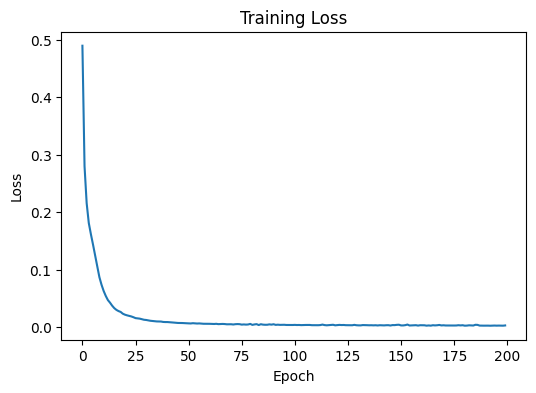

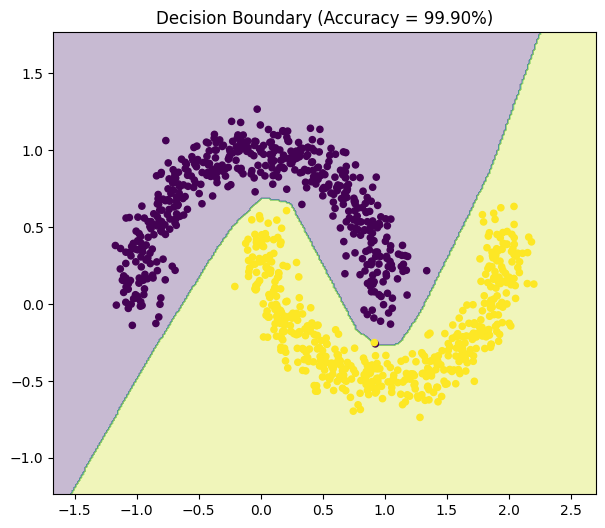

In [38]:
# Your code here
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset, DataLoader

# ===================================================
# Custom ReLU
# ===================================================

class MyReLU(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        ctx.save_for_backward(x)

        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):

        (x,) = ctx.saved_tensors

        grad_x = grad_output.clone()

        grad_x[x <= 0] = 0

        return grad_x


def my_relu(x):
    return MyReLU.apply(x)

# ===================================================
# Custom Cross Entropy
# ===================================================

def my_cross_entropy(logits, targets):

    m = logits.max(dim=1, keepdim=True).values

    logsumexp = m + torch.log(
        torch.sum(
            torch.exp(logits - m),
            dim=1,
            keepdim=True
        )
    )

    log_probs = logits - logsumexp

    N = logits.shape[0]

    correct = log_probs[
        torch.arange(N),
        targets
    ]

    return -correct.mean()

# ===================================================
# Gradient clipping
# ===================================================

@torch.no_grad()
def clip_grad_norm(params, max_norm):

    params = list(params)

    total_norm_sq = 0.0

    for p in params:

        if p.grad is None:
            continue

        total_norm_sq += p.grad.pow(2).sum()

    total_norm = torch.sqrt(total_norm_sq)

    if total_norm > max_norm:

        scale = max_norm / (total_norm + 1e-6)

        for p in params:

            if p.grad is None:
                continue

            p.grad.mul_(scale)

# ===================================================
# Custom Adam
# ===================================================

class MyAdam:

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8
    ):

        self.params = list(params)

        self.lr = lr

        self.beta1, self.beta2 = betas

        self.eps = eps

        self.state = {
            id(p): {} for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            grad = p.grad

            state = self.state[id(p)]

            if len(state) == 0:

                state["t"] = 0

                state["m"] = torch.zeros_like(p)

                state["v"] = torch.zeros_like(p)

            state["t"] += 1

            t = state["t"]

            m = state["m"]

            v = state["v"]

            m.mul_(self.beta1).add_(
                grad,
                alpha=1 - self.beta1
            )

            v.mul_(self.beta2).addcmul_(
                grad,
                grad,
                value=1 - self.beta2
            )

            m_hat = m / (1 - self.beta1 ** t)

            v_hat = v / (1 - self.beta2 ** t)

            p -= self.lr * m_hat / (
                torch.sqrt(v_hat) + self.eps
            )

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

# ===================================================
# Dataset
# ===================================================

X, y = make_moons(
    n_samples=1000,
    noise=0.1,
    random_state=0
)

X = torch.tensor(X, dtype=torch.float32)

y = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X, y)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

# ===================================================
# Model
# ===================================================

class MoonMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(2, 32)

        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):

        x = self.fc1(x)

        x = my_relu(x)

        x = self.fc2(x)

        return x

model = MoonMLP()

# ===================================================
# Optimizer
# ===================================================

optimizer = MyAdam(
    model.parameters(),
    lr=1e-2
)

# ===================================================
# Training
# ===================================================

losses = []

epochs = 200

for epoch in range(epochs):

    total_loss = 0.0

    for xb, yb in loader:

        logits = model(xb)

        loss = my_cross_entropy(
            logits,
            yb
        )

        optimizer.zero_grad()

        loss.backward()

        # Gradient clipping
        clip_grad_norm(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(dataset)

    losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss = {avg_loss:.4f}"
        )

# ===================================================
# Accuracy
# ===================================================

with torch.no_grad():

    logits = model(X)

    preds = logits.argmax(dim=1)

    acc = (preds == y).float().mean()

print(f"\nFinal accuracy: {acc.item()*100:.2f}%")

# ===================================================
# Plot training loss
# ===================================================

plt.figure(figsize=(6, 4))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

# ===================================================
# Decision boundary
# ===================================================

x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5

y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 300),
    torch.linspace(y_min, y_max, 300),
    indexing='ij'
)

grid = torch.stack(
    [xx.flatten(), yy.flatten()],
    dim=1
)

with torch.no_grad():

    logits = model(grid)

    zz = logits.argmax(dim=1)

Z = zz.reshape(xx.shape)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx.numpy(),
    yy.numpy(),
    Z.numpy(),
    alpha=0.3
)

plt.scatter(
    X[:,0].numpy(),
    X[:,1].numpy(),
    c=y.numpy(),
    s=20
)

plt.title(
    f"Decision Boundary (Accuracy = {acc.item()*100:.2f}%)"
)

plt.show()

---
## Where to go next

If you finished the above:
- Re-do Exercise 7.4 (Adam) so that it supports **parameter groups** (different `lr` per group), like real `torch.optim` optimizers.
- Write a custom autograd function for **batch-norm** (forward + backward by hand) and compare against `nn.BatchNorm1d`.
- Read the source of `torch.optim.Adam` and `torch.nn.functional.cross_entropy` and compare them to your implementations.
- Look at `torch.func` (functorch) — `grad`, `vmap`, `jacrev` — and re-do the Hessian exercise in one line.